# Hospital Readmission — Exploratory Data Analysis

This notebook covers **exploration only**: raw shape, target distribution, and missing-value patterns on the original `diabetic_data.csv`.

The full cleaning pipeline (patient deduplication, hospice/expired removal, leakage-safe diagnosis/specialty grouping) and the CatBoost model are implemented in `train.py`, not here — see the main README for details. Numbers shown below are on the **raw, unfiltered dataset** (101,766 rows) and will not match the cleaned counts reported elsewhere (69,169 rows).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/diabetic_data.csv')
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
print("Shape:", df.shape)
print("\n")
print(df['readmitted'].value_counts())

Shape: (101766, 50)


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


readmitted_binary
0    90409
1    11357
Name: count, dtype: int64


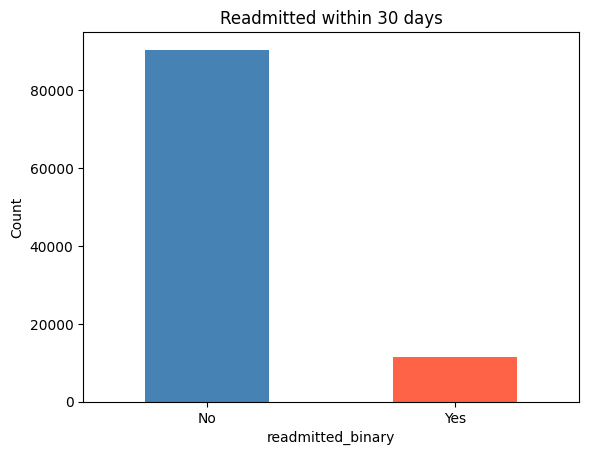

In [9]:
# แปลง readmitted เป็น binary
# <30 = 1 (readmitted เร็ว = ต้องการความสนใจ)
# NO และ >30 = 0

df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
print(df['readmitted_binary'].value_counts())

# plot ดูการกระจาย
df['readmitted_binary'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Readmitted within 30 days')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.ylabel('Count')
plt.show()

In [10]:
# เช็ค missing values
missing = df.isin(['?']).sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


## Next steps

The missing-value pattern above (`weight`, `medical_specialty`, `payer_code` mostly missing; `diag_1/2/3` rarely missing) is what motivated the cleaning decisions documented in the README and implemented in `train.py`:

- Drop `weight` and `payer_code` (too sparse to be useful)
- Keep `diag_1/2/3`, grouping missing values into `"Other"` instead of dropping rows
- Deduplicate to one encounter per patient and remove hospice/expired discharges before modeling

See `train.py` for the full leakage-aware pipeline and model training.